In [ ]:
import kagglehub
path = kagglehub.dataset_download("mewbius/ecommerce-products")

Using Colab cache for faster access to the 'ecommerce-products' dataset.


In [ ]:
import os
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import GPT2Tokenizer, GPT2LMHeadModel

In [ ]:
# Load the specific file
csv_path = os.path.join(path, "productsfull2.csv")
df = pd.read_csv(csv_path)

print(f"Dataset loaded ✓ | Shape: {df.shape}")
df.head()

Dataset loaded ✓ | Shape: (24714, 9)


,colorname,desc2,description,fit,fitinfo,fulldescription,itemid,name,url
0,[],[],"[""The world's #1-selling hunting knife in its ...",[],[],"[""The world's #1-selling hunting knife in its ...",['219529'],Buck 110 Folding Hunter's Knife,https://www.llbean.com/llb/shop/38592?page=buc...
1,"['Bright Sapphire', 'Cactus', 'Night', 'Teal S...",[],"[""We've combined the freedom of a sandal with ...",[],['Half sizes order down.'],"[""We've combined the freedom of a sandal with ...",['504069'],Kids' Explorer Sandals,https://www.llbean.com/llb/shop/120346?page=ki...
2,['Mossy Oak Country'],"[""Maine State Game Wardens are the pinnacle of...","[""This is the ultimate sportsman's day pack. D...",[],[],"[""This is the ultimate sportsman's day pack. D...",['505356'],"Maine Warden's Day Pack, Camo",https://www.llbean.com/llb/shop/121924?page=ma...
3,['Owl'],[],['These fur-ocious kids’ animal slippers will ...,[],"['Half sizes order up.', 'Sized for toddlers.']",['These fur-ocious kids’ animal slippers will ...,['219943'],Toddlers' Animal Paws Slippers,https://www.llbean.com/llb/shop/38106?page=tod...
4,['Dark Gray Multi'],[],['Our Baby Bogs set the standard in toddlers’ ...,[],[],['Our Baby Bogs set the standard in toddlers’ ...,['306187'],"Toddlers' Baby Bogs Boots, Classic Dino",https://www.llbean.com/llb/shop/118942?page=to...


In [ ]:
print(df.columns)

Index(['colorname', 'desc2', 'description', 'fit', 'fitinfo',
       'fulldescription', 'itemid', 'name', 'url'],
      dtype='object')


In [ ]:
(df == "[]").sum()

,0
colorname,616
desc2,18207
description,286
fit,21319
fitinfo,11382
fulldescription,0
itemid,7432
name,0
url,0


In [ ]:
df = df[['name', 'fulldescription', 'colorname']]

In [ ]:
df.replace("[]", np.nan, inplace=True)

In [ ]:
df = df.dropna(subset=['fulldescription'])

In [ ]:
df['colorname'] = df['colorname'].fillna('unknown')

In [ ]:
print(df.shape)
df.isnull().sum()

(24714, 3)


,0
name,0
fulldescription,0
colorname,0


In [ ]:
df['fulldescription'].str.len().describe()

,fulldescription
count,24714.000000
mean,1047.272437
std,743.538204
min,37.000000
25%,617.000000
50%,817.000000
75%,1128.000000
max,5035.000000


In [ ]:
# TEXT CLEANING
import re
import ast
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Parse string-represented lists into plain text
def parse_list_column(val):
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return ' '.join([str(i) for i in parsed])
        return str(parsed)
    except:
        return str(val)

df['fulldescription_clean'] = df['fulldescription'].apply(parse_list_column)
df['colorname_clean']       = df['colorname'].apply(parse_list_column)
df['name_clean']            = df['name'].str.lower().str.strip()

In [ ]:
# Remove CSS blocks, HTML tags, URLs, special characters
def clean_text(text):
    text = re.sub(r'#[\w-]+\s*\{[^}]*\}', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\'"-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    return text

df['fulldescription_clean'] = df['fulldescription_clean'].apply(clean_text)
df['name_clean']            = df['name_clean'].apply(clean_text)

In [ ]:
#Light stopword removal
light_stopwords = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'it', 'its', 'this', 'that'}

def remove_stopwords(text):
    tokens = word_tokenize(text)
    return ' '.join([w for w in tokens if w not in light_stopwords])

df['fulldescription_clean'] = df['fulldescription_clean'].apply(remove_stopwords)

In [ ]:
# Drop duplicate descriptions & reset index
df.drop_duplicates(subset=['fulldescription_clean'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Rows after cleaning: {df.shape[0]}")
df[['name_clean', 'fulldescription_clean']].head(3)

Rows after cleaning: 4653


,name_clean,fulldescription_clean
0,buck 110 folding hunter's knife,world 's 1-selling hunting knife in original l...
1,kids' explorer sandals,we 've combined freedom of sandal with closed-...
2,"maine warden's day pack, camo",ultimate sportsman 's day pack . designed with...


In [ ]:
# FEATURE EXTRACTION
df['desc_word_count'] = df['fulldescription_clean'].apply(lambda x: len(x.split()))
df['desc_word_count'].describe()

,desc_word_count
count,4653.000000
mean,145.646894
std,75.636376
min,5.000000
25%,94.000000
50%,125.000000
75%,173.000000
max,538.000000


In [ ]:
# Extract colors
def extract_colors(val):
    try:
        parsed = ast.literal_eval(val) if val != 'unknown' else []
        if isinstance(parsed, list):
            return ', '.join([c.strip().lower() for c in parsed])
    except:
        pass
    return 'unknown'

df['colors_extracted'] = df['colorname'].apply(extract_colors)
df[['name', 'colors_extracted']].head(5)

,name,colors_extracted
0,Buck 110 Folding Hunter's Knife,
1,Kids' Explorer Sandals,"bright sapphire, cactus, night, teal shadow"
2,"Maine Warden's Day Pack, Camo",mossy oak country
3,Toddlers' Animal Paws Slippers,owl
4,"Toddlers' Baby Bogs Boots, Classic Dino",dark gray multi


In [ ]:
# Filter
before = df.shape[0]
df = df[df['desc_word_count'] >= 20].reset_index(drop=True)
print(f"Removed {before - df.shape[0]} short entries | Remaining: {df.shape[0]}")

Removed 2 short entries | Remaining: 4651


In [ ]:
# Save cleaned
output_cols = ['name_clean', 'fulldescription_clean', 'colors_extracted', 'desc_word_count']
df[output_cols].to_csv('cleaned_features.csv', index=False)
print("Saved: cleaned_features.csv ✓")
df[output_cols].head(3)

Saved: cleaned_features.csv ✓


,name_clean,fulldescription_clean,colors_extracted,desc_word_count
0,buck 110 folding hunter's knife,world 's 1-selling hunting knife in original l...,,137
1,kids' explorer sandals,we 've combined freedom of sandal with closed-...,"bright sapphire, cactus, night, teal shadow",75
2,"maine warden's day pack, camo",ultimate sportsman 's day pack . designed with...,mossy oak country,337


In [ ]:
import pandas as pd

df = pd.read_csv("cleaned_features.csv")

print("Dataset loaded ✓")
print("Shape:", df.shape)

df.head()

Dataset loaded ✓
Shape: (4651, 4)


,name_clean,fulldescription_clean,colors_extracted,desc_word_count
0,buck 110 folding hunter's knife,world 's 1-selling hunting knife in original l...,NaN,137
1,kids' explorer sandals,we 've combined freedom of sandal with closed-...,"bright sapphire, cactus, night, teal shadow",75
2,"maine warden's day pack, camo",ultimate sportsman 's day pack . designed with...,mossy oak country,337
3,toddlers' animal paws slippers,these fur-ocious kids animal slippers will sti...,owl,87
4,"toddlers' baby bogs boots, classic dino",our baby bogs set standard in toddlers handle ...,dark gray multi,72


In [ ]:
def build_prompt(row):

    name = row['name_clean']
    colors = row['colors_extracted']
    desc = row['fulldescription_clean']

    prompt = f"""Product: {name}
Color: {colors}
Description: {desc}
"""

    return prompt

df["prompt"] = df.apply(build_prompt, axis=1)

df[['prompt']].head(3)

,prompt
0,Product: buck 110 folding hunter's knife\nColo...
1,Product: kids' explorer sandals\nColor: bright...
2,"Product: maine warden's day pack, camo\nColor:..."


In [ ]:
df["prompt_length"] = df["prompt"].apply(lambda x: len(x.split()))

print(df["prompt_length"].describe())

count    4651.000000
mean      157.407439
std        76.110235
min        42.000000
25%       106.000000
50%       137.000000
75%       185.000000
max       552.000000
Name: prompt_length, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42
)

print("Train size:", train_df.shape)
print("Validation size:", val_df.shape)

Train size: (4185, 6)
Validation size: (466, 6)


In [ ]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

train_df.head(2)

,name_clean,fulldescription_clean,colors_extracted,desc_word_count,prompt,prompt_length
0,native wells polarized sunglasses,native wells polarized sunglasses have all sty...,"dark crystal brown/brown, satin black/gray",123,Product: native wells polarized sunglasses\nCo...,135
1,"streamlight ultra ii two-handed fly rod, 7-9 wt.",affordable rod great way to learn two-handed a...,green,133,Product: streamlight ultra ii two-handed fly r...,145


In [ ]:
train_df[['prompt']].to_csv("train_prompts.csv", index=False)
val_df[['prompt']].to_csv("val_prompts.csv", index=False)

print("Files saved ✓")

Files saved ✓


In [ ]:
print(train_df.columns)

Index(['name_clean', 'fulldescription_clean', 'colors_extracted',
       'desc_word_count', 'prompt', 'prompt_length'],
      dtype='object')


In [ ]:
df

,name_clean,fulldescription_clean,colors_extracted,desc_word_count,prompt,prompt_length
0,buck 110 folding hunter's knife,world 's 1-selling hunting knife in original l...,NaN,137,Product: buck 110 folding hunter's knife\nColo...,146
1,kids' explorer sandals,we 've combined freedom of sandal with closed-...,"bright sapphire, cactus, night, teal shadow",75,Product: kids' explorer sandals\nColor: bright...,87
2,"maine warden's day pack, camo",ultimate sportsman 's day pack . designed with...,mossy oak country,337,"Product: maine warden's day pack, camo\nColor:...",348
3,toddlers' animal paws slippers,these fur-ocious kids animal slippers will sti...,owl,87,Product: toddlers' animal paws slippers\nColor...,95
4,"toddlers' baby bogs boots, classic dino",our baby bogs set standard in toddlers handle ...,dark gray multi,72,"Product: toddlers' baby bogs boots, classic di...",84
...,...,...,...,...,...,...
4646,blooming circles quilt collection,100 cotton quilt handmade in style of traditio...,multi color,149,Product: blooming circles quilt collection\nCo...,158
4647,"sunwashed percale sheet collection, print",youll love our softest percale sheet set for d...,"blue mist, driftwood, rustic blue",233,"Product: sunwashed percale sheet collection, p...",246
4648,lakeside percale sheet collection,"perfect for home or camp , our beautiful outdo...",multi,230,Product: lakeside percale sheet collection\nCo...,238
4649,classic colors down comforter,designed to match your surroundings without co...,"mariner blue, new khaki, silver moon, soft blu...",207,Product: classic colors down comforter\nColor:...,224


In [ ]:
from transformers import GPT2Tokenizer
from datasets import Dataset

print("Loading GPT-2 Tokenizer...")
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')


tokenizer.pad_token = tokenizer.eos_token

train_dataset = Dataset.from_pandas(train_df[['prompt']])
val_dataset = Dataset.from_pandas(val_df[['prompt']])

def tokenize_function(examples):

    return tokenizer(
        examples["prompt"],
        padding="max_length",
        truncation=True,
        max_length=256
    )


print("Tokenizing training data...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)

print("Tokenizing validation data...")
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_train = tokenized_train.map(lambda x: {'labels': x['input_ids']}, batched=True)
tokenized_val = tokenized_val.map(lambda x: {'labels': x['input_ids']}, batched=True)

tokenized_train.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
tokenized_val.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

print("Tokenization complete ✓")
print(f"Sample train input shape: {tokenized_train[0]['input_ids'].shape}")

Loading GPT-2 Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Tokenizing validation data...


Map:   0%|          | 0/466 [00:00<?, ? examples/s]

Map:   0%|          | 0/4185 [00:00<?, ? examples/s]

Map:   0%|          | 0/466 [00:00<?, ? examples/s]

Tokenization complete ✓
Sample train input shape: torch.Size([256])


In [ ]:
df['text'] = df['name_clean'].astype(str) + " " + df['fulldescription_clean'].astype(str)

In [ ]:
df['text']

,text
0,buck 110 folding hunter's knife world 's 1-sel...
1,kids' explorer sandals we 've combined freedom...
2,"maine warden's day pack, camo ultimate sportsm..."
3,toddlers' animal paws slippers these fur-ociou...
4,"toddlers' baby bogs boots, classic dino our ba..."
...,...
4646,blooming circles quilt collection 100 cotton q...
4647,"sunwashed percale sheet collection, print youl..."
4648,lakeside percale sheet collection perfect for ...
4649,classic colors down comforter designed to matc...


In [ ]:
df

,name_clean,fulldescription_clean,colors_extracted,desc_word_count,prompt,prompt_length,text
0,buck 110 folding hunter's knife,world 's 1-selling hunting knife in original l...,NaN,137,Product: buck 110 folding hunter's knife\nColo...,146,buck 110 folding hunter's knife world 's 1-sel...
1,kids' explorer sandals,we 've combined freedom of sandal with closed-...,"bright sapphire, cactus, night, teal shadow",75,Product: kids' explorer sandals\nColor: bright...,87,kids' explorer sandals we 've combined freedom...
2,"maine warden's day pack, camo",ultimate sportsman 's day pack . designed with...,mossy oak country,337,"Product: maine warden's day pack, camo\nColor:...",348,"maine warden's day pack, camo ultimate sportsm..."
3,toddlers' animal paws slippers,these fur-ocious kids animal slippers will sti...,owl,87,Product: toddlers' animal paws slippers\nColor...,95,toddlers' animal paws slippers these fur-ociou...
4,"toddlers' baby bogs boots, classic dino",our baby bogs set standard in toddlers handle ...,dark gray multi,72,"Product: toddlers' baby bogs boots, classic di...",84,"toddlers' baby bogs boots, classic dino our ba..."
...,...,...,...,...,...,...,...
4646,blooming circles quilt collection,100 cotton quilt handmade in style of traditio...,multi color,149,Product: blooming circles quilt collection\nCo...,158,blooming circles quilt collection 100 cotton q...
4647,"sunwashed percale sheet collection, print",youll love our softest percale sheet set for d...,"blue mist, driftwood, rustic blue",233,"Product: sunwashed percale sheet collection, p...",246,"sunwashed percale sheet collection, print youl..."
4648,lakeside percale sheet collection,"perfect for home or camp , our beautiful outdo...",multi,230,Product: lakeside percale sheet collection\nCo...,238,lakeside percale sheet collection perfect for ...
4649,classic colors down comforter,designed to match your surroundings without co...,"mariner blue, new khaki, silver moon, soft blu...",207,Product: classic colors down comforter\nColor:...,224,classic colors down comforter designed to matc...


In [ ]:
lengths = [len(tokenizer(x["prompt"])["input_ids"]) for x in train_dataset]

print("Max length:", max(lengths))
print("Min length:", min(lengths))

Max length: 923
Min length: 58


In [ ]:
lengths = [len(x['input_ids']) for x in tokenized_train]

print("Max length:", max(lengths))
print("Min length:", min(lengths))

Max length: 256
Min length: 256


Max length: 923
Min length: 58


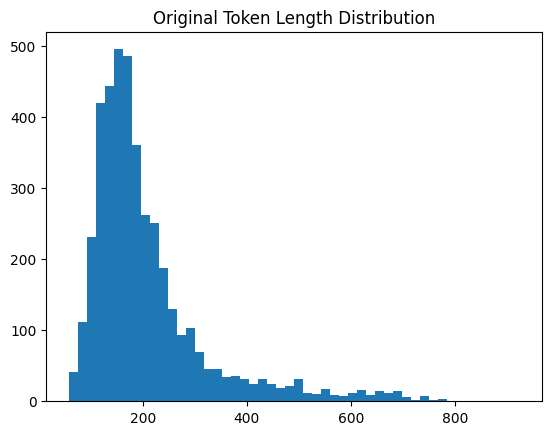

In [ ]:
lengths = [len(tokenizer(x["prompt"])["input_ids"]) for x in train_dataset]

print("Max length:", max(lengths))
print("Min length:", min(lengths))

import matplotlib.pyplot as plt
plt.hist(lengths, bins=50)
plt.title("Original Token Length Distribution")
plt.show()

In [ ]:
from transformers import GPT2LMHeadModel

model = GPT2LMHeadModel.from_pretrained("gpt2")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
from peft import LoraConfig, get_peft_model
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["c_attn"],  # important for GPT-2
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 294,912 || all params: 124,734,720 || trainable%: 0.2364


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    save_strategy="epoch",
    logging_steps=50,
    save_total_limit=2,
    fp16=True,
    report_to="none",
    learning_rate=2e-4,
    warmup_steps=100
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val
)

trainer.train()

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
50,5.826837
100,3.949180
150,3.193868
200,3.118413
250,2.970028
300,3.043652
350,3.158124
400,2.928793
450,2.768548
500,2.766183


TrainOutput(global_step=6279, training_loss=2.5559107104120864, metrics={'train_runtime': 357.9022, 'train_samples_per_second': 35.079, 'train_steps_per_second': 17.544, 'total_flos': 1645947955445760.0, 'train_loss': 2.5559107104120864, 'epoch': 3.0})

In [ ]:
#### not run

model.save_pretrained("lora_model")
tokenizer.save_pretrained("lora_model")

In [ ]:
#### not run

from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="lora_model",   # or your saved path
    tokenizer=tokenizer
)

prompt = """Product Name: Casual Cotton T-Shirt
Color: White
Description:"""

output = generator(prompt, max_length=120)
print(output[0]["generated_text"])

NameError: name 'df' is not defined